# Model 000: Dumb Baselines

This notebook builds simple baseline models for:

- `recommended` (binary sentiment target)
- `votes_helpful` (count helpfulness target)
- `is_helpful` (binary helpfulness target, derived as `votes_helpful >= 1`)

These baselines are intentionally simple and set a floor that stronger models should beat.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import plotly.graph_objects as go

from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    fbeta_score,
    mean_absolute_error,
    mean_squared_error,
    precision_score,
    precision_recall_curve,
    r2_score,
    recall_score,
    matthews_corrcoef,
    roc_auc_score,
    roc_curve,
)

SEED = 2026
rng = np.random.default_rng(SEED)

base_dir = Path("../../data/processed")
train_path = base_dir / "steam_reviews_cleaned_english_train.parquet"
val_path = base_dir / "steam_reviews_cleaned_english_val.parquet"
# test_path = base_dir / "steam_reviews_cleaned_english_test.parquet"

for p in (train_path, val_path):
    if not p.exists():
        raise FileNotFoundError(f"Missing split parquet: {p}")

print("Train:", train_path)
print("Val:  ", val_path)
# print("Test: ", test_path)

Train: ../../data/processed/steam_reviews_cleaned_english_train.parquet
Val:   ../../data/processed/steam_reviews_cleaned_english_val.parquet


In [2]:
train_df = pd.read_parquet(train_path)
val_df = pd.read_parquet(val_path)
# test_df = pd.read_parquet(test_path)

for df in (train_df, val_df):
    if "is_helpful" not in df.columns:
        df["is_helpful"] = df["votes_helpful"] >= 1
    df["is_helpful"] = df["is_helpful"].astype(int)
    df["recommended"] = df["recommended"].astype(int)

# Fit baseline parameters on train only
p_helpful = train_df["is_helpful"].mean()
majority_helpful = int(train_df["is_helpful"].mode().iloc[0])

p_rec = train_df["recommended"].mean()
majority_rec = int(train_df["recommended"].mode().iloc[0])

helpful_train = train_df["votes_helpful"].astype(float)
mean_helpful = helpful_train.mean()
value_probs = helpful_train.value_counts(normalize=True).sort_index()
values = value_probs.index.to_numpy()
probs = value_probs.values

# Build baseline prediction columns once (deterministic RNG streams)
rng_helpful = np.random.default_rng(SEED + 1)
rng_recommended = np.random.default_rng(SEED + 2)
rng_votes = np.random.default_rng(SEED + 3)

for df in (train_df, val_df):
    # is_helpful baselines
    df["is_helpful_pred_majority"] = majority_helpful
    df["is_helpful_pred_prev_rand"] = rng_helpful.binomial(1, p_helpful, size=len(df))

    # recommended baselines
    df["recommended_pred_majority"] = majority_rec
    df["recommended_pred_prev_rand"] = rng_recommended.binomial(1, p_rec, size=len(df))

    # votes_helpful baselines
    df["votes_helpful_pred_all_zero"] = 0.0
    df["votes_helpful_pred_train_mean"] = mean_helpful
    df["votes_helpful_pred_empirical_random"] = rng_votes.choice(values, size=len(df), p=probs)

print(f"train shape: {train_df.shape}")
print(f"val shape:   {val_df.shape}")
print("Baseline prediction columns added to train_df and val_df")
# print(f"test shape:  {test_df.shape}")

train shape: (6410755, 26)
val shape:   (1374737, 26)
Baseline prediction columns added to train_df and val_df


# Custom Functions

In [3]:
def classification_metrics(y_true, y_pred, y_score=None):
    """
    Binary classification metrics (positive class = 1).

    Parameters
    ----------
    y_true : array-like
        Ground-truth labels (0/1).
    y_pred : array-like
        Predicted labels (0/1).
    y_score : array-like | None
        Continuous score/probability for positive class. Needed for AUPRC.
        If None, falls back to y_pred as a coarse score proxy.

    Also returns specificity and MCC from the 2x2 confusion matrix (positive class = 1).
    """
    y_true = np.asarray(y_true, dtype=int)
    y_pred = np.asarray(y_pred, dtype=int)
    if y_score is None:
        y_score = y_pred
    y_score = np.asarray(y_score, dtype=float)

    # Binary confusion (positive class = 1): TN, FP, _, _
    tn, fp, _, _ = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    neg_denom = tn + fp
    specificity = (tn / neg_denom) if neg_denom > 0 else 0.0

    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "f2": fbeta_score(y_true, y_pred, beta=2, zero_division=0),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "specificity": specificity,
        "mcc": matthews_corrcoef(y_true, y_pred),
        "auprc": average_precision_score(y_true, y_score),
        "roc_auc": roc_auc_score(y_true, y_score),
    }


def regression_metrics(y_true, y_pred, eps=1e-8):
    """
    Common regression metrics:
    - MAE
    - MSE
    - RMSE
    - R2
    - MAPE (safe denominator to avoid divide-by-zero)
    """
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    # MAPE can explode when y_true is near 0; use safe denominator.
    denom = np.maximum(np.abs(y_true), eps)
    mape = np.mean(np.abs((y_true - y_pred) / denom)) * 100.0

    return {
        "mae": mae,
        "mse": mse,
        "rmse": rmse,
        "r2": r2,
        "mape_pct": mape,
    }


def as_table(rows):
    return pd.DataFrame(rows).sort_values(["target", "baseline"]).reset_index(drop=True)

In [4]:
def by_game_classification_metrics(df, y_col, pred_col, score_col=None, min_rows=200):
    rows = []
    for game, g in df.groupby("app_name"):
        if len(g) < min_rows:
            continue

        y_true = g[y_col].astype(int).to_numpy()
        y_pred = g[pred_col].astype(int).to_numpy()
        y_score = g[score_col].to_numpy() if score_col is not None else None

        m = classification_metrics(y_true, y_pred, y_score=y_score)
        rows.append({"app_name": game, "n_rows": len(g), **m})

    out = pd.DataFrame(rows)
    if len(out) == 0:
        return out
    return out.sort_values(["f1", "auprc"], ascending=[False, False]).reset_index(drop=True)

In [5]:
def by_binned_classification_metrics(
    df,
    y_col,
    pred_col,
    bin_field,
    n_bins=10,
    score_col=None,
    min_rows=100,
    strategy="quantile",  # "quantile" or "equal_width"
    include_zero_flag=False,  # useful for zero-heavy fields like votes_helpful
):
    """
    Compute classification metrics by bins of a numeric field.

    Parameters
    ----------
    df : pd.DataFrame
    y_col : str
        True binary label column (0/1).
    pred_col : str
        Predicted binary label column (0/1).
    bin_field : str
        Numeric column to bin (e.g., review_length_chars, votes_helpful, author.playtime_at_review).
    n_bins : int
        Number of bins.
    score_col : str | None
        Optional score/probability column for AUPRC.
    min_rows : int
        Minimum rows per bin to report.
    strategy : str
        "quantile" for qcut, "equal_width" for cut.
    include_zero_flag : bool
        If True, includes a separate boolean group (bin_field == 0) before binning.
        Useful for highly zero-inflated fields.
    """
    work = df[[y_col, pred_col, bin_field] + ([score_col] if score_col else [])].copy()

    # Build bin labels
    if strategy == "quantile":
        work["_bin"] = pd.qcut(work[bin_field], q=n_bins, duplicates="drop")
    elif strategy == "equal_width":
        work["_bin"] = pd.cut(work[bin_field], bins=n_bins, include_lowest=True)
    else:
        raise ValueError("strategy must be 'quantile' or 'equal_width'")

    rows = []

    # Optional zero vs non-zero segment
    if include_zero_flag:
        for zero_flag, g0 in work.groupby(work[bin_field] == 0):
            if len(g0) < min_rows:
                continue
            y_true = g0[y_col].astype(int).to_numpy()
            y_pred = g0[pred_col].astype(int).to_numpy()
            y_score = g0[score_col].to_numpy() if score_col else None
            m = classification_metrics(y_true, y_pred, y_score=y_score)
            rows.append({
                "segment_type": "zero_flag",
                "segment": f"{bin_field}==0:{zero_flag}",
                "n_rows": len(g0),
                **m
            })

    # Binned segments
    for b, g in work.groupby("_bin", observed=False):
        if pd.isna(b) or len(g) < min_rows:
            continue
        y_true = g[y_col].astype(int).to_numpy()
        y_pred = g[pred_col].astype(int).to_numpy()
        y_score = g[score_col].to_numpy() if score_col else None
        m = classification_metrics(y_true, y_pred, y_score=y_score)
        rows.append({
            "segment_type": "bin",
            "segment": str(b),
            "n_rows": len(g),
            "bin_field": bin_field,
            **m
        })

    out = pd.DataFrame(rows)
    if len(out) == 0:
        return out
    return out.sort_values(["segment_type", "f1", "auprc"], ascending=[True, False, False]).reset_index(drop=True)

In [6]:
def plot_binned_metrics(
    binned_df,
    metrics=("f1", "auprc"),
    title="Binned classification metrics",
    rotate_xticks=45,
):
    """
    Quick plot for metric values by segment/bin.
    Expects output from by_binned_classification_metrics(...).
    """
    if binned_df is None or len(binned_df) == 0:
        print("No rows to plot.")
        return

    plot_df = binned_df.copy()

    # Keep bins ordered as they appear if possible
    plot_df["segment"] = plot_df["segment"].astype(str)

    n_metrics = len(metrics)
    fig, axes = plt.subplots(1, n_metrics, figsize=(7 * n_metrics, 5), squeeze=False)

    for i, m in enumerate(metrics):
        ax = axes[0, i]
        if m not in plot_df.columns:
            ax.set_title(f"{m} (missing)")
            ax.axis("off")
            continue

        ax.bar(plot_df["segment"], plot_df[m])
        ax.set_title(f"{m.upper()} by segment")
        ax.set_xlabel("Segment")
        ax.set_ylabel(m.upper())
        ax.tick_params(axis="x", rotation=rotate_xticks)
        ax.grid(axis="y", alpha=0.2)

        # Optional value labels
        for x, y in zip(plot_df["segment"], plot_df[m]):
            if pd.notna(y):
                ax.text(x, y, f"{y:.3f}", ha="center", va="bottom", fontsize=8, rotation=0)

    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

In [7]:
def plot_binary_pr_curves(
    train_df,
    val_df,
    target_col,
    pred_majority_col,
    pred_random_col,
    target_name=None,
):
    """Plot train/val PR curves for binary baselines using dataframe columns."""
    label = target_name or target_col

    y_train = train_df[target_col].astype(int).to_numpy()
    y_val = val_df[target_col].astype(int).to_numpy()

    score_train_majority = train_df[pred_majority_col].astype(float).to_numpy()
    score_val_majority = val_df[pred_majority_col].astype(float).to_numpy()

    score_train_rand = train_df[pred_random_col].astype(float).to_numpy()
    score_val_rand = val_df[pred_random_col].astype(float).to_numpy()

    prec_tr_maj, rec_tr_maj, _ = precision_recall_curve(y_train, score_train_majority)
    prec_va_maj, rec_va_maj, _ = precision_recall_curve(y_val, score_val_majority)

    prec_tr_rand, rec_tr_rand, _ = precision_recall_curve(y_train, score_train_rand)
    prec_va_rand, rec_va_rand, _ = precision_recall_curve(y_val, score_val_rand)

    ap_tr_maj = average_precision_score(y_train, score_train_majority)
    ap_va_maj = average_precision_score(y_val, score_val_majority)
    ap_tr_rand = average_precision_score(y_train, score_train_rand)
    ap_va_rand = average_precision_score(y_val, score_val_rand)

    no_skill_train = y_train.mean()
    no_skill_val = y_val.mean()

    fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

    axes[0].plot(rec_tr_maj, prec_tr_maj, label=f"Majority (AP={ap_tr_maj:.3f})")
    axes[0].plot(rec_tr_rand, prec_tr_rand, label=f"Prevalence-random (AP={ap_tr_rand:.3f})")
    axes[0].hlines(no_skill_train, 0, 1, colors="gray", linestyles="--", label=f"No-skill={no_skill_train:.3f}")
    axes[0].set_title(f"PR Curve - {label} (Train)")
    axes[0].set_xlabel("Recall")
    axes[0].set_ylabel("Precision")
    axes[0].set_xlim(0, 1)
    axes[0].set_ylim(0, 1.05)
    axes[0].grid(alpha=0.2)
    axes[0].legend()

    axes[1].plot(rec_va_maj, prec_va_maj, label=f"Majority (AP={ap_va_maj:.3f})")
    axes[1].plot(rec_va_rand, prec_va_rand, label=f"Prevalence-random (AP={ap_va_rand:.3f})")
    axes[1].hlines(no_skill_val, 0, 1, colors="gray", linestyles="--", label=f"No-skill={no_skill_val:.3f}")
    axes[1].set_title(f"PR Curve - {label} (Val)")
    axes[1].set_xlabel("Recall")
    axes[1].set_xlim(0, 1)
    axes[1].set_ylim(0, 1.05)
    axes[1].grid(alpha=0.2)
    axes[1].legend()

    plt.tight_layout()
    plt.show()

In [8]:
def plot_binary_roc_curves(
    train_df,
    val_df,
    target_col,
    pred_majority_col,
    pred_random_col,
    target_name=None,
):
    """Plot train/val ROC curves for binary baselines using dataframe columns."""
    label = target_name or target_col

    y_train = train_df[target_col].astype(int).to_numpy()
    y_val = val_df[target_col].astype(int).to_numpy()

    score_train_majority = train_df[pred_majority_col].astype(float).to_numpy()
    score_val_majority = val_df[pred_majority_col].astype(float).to_numpy()

    score_train_rand = train_df[pred_random_col].astype(float).to_numpy()
    score_val_rand = val_df[pred_random_col].astype(float).to_numpy()

    fpr_tr_maj, tpr_tr_maj, _ = roc_curve(y_train, score_train_majority)
    fpr_va_maj, tpr_va_maj, _ = roc_curve(y_val, score_val_majority)

    fpr_tr_rand, tpr_tr_rand, _ = roc_curve(y_train, score_train_rand)
    fpr_va_rand, tpr_va_rand, _ = roc_curve(y_val, score_val_rand)

    auc_tr_maj = roc_auc_score(y_train, score_train_majority)
    auc_va_maj = roc_auc_score(y_val, score_val_majority)
    auc_tr_rand = roc_auc_score(y_train, score_train_rand)
    auc_va_rand = roc_auc_score(y_val, score_val_rand)

    fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

    axes[0].plot(fpr_tr_maj, tpr_tr_maj, label=f"Majority (AUC={auc_tr_maj:.3f})")
    axes[0].plot(fpr_tr_rand, tpr_tr_rand, label=f"Prevalence-random (AUC={auc_tr_rand:.3f})")
    axes[0].plot([0, 1], [0, 1], linestyle="--", color="gray", label="No-skill")
    axes[0].set_title(f"ROC Curve - {label} (Train)")
    axes[0].set_xlabel("False Positive Rate")
    axes[0].set_ylabel("True Positive Rate")
    axes[0].set_xlim(0, 1)
    axes[0].set_ylim(0, 1.05)
    axes[0].grid(alpha=0.2)
    axes[0].legend()

    axes[1].plot(fpr_va_maj, tpr_va_maj, label=f"Majority (AUC={auc_va_maj:.3f})")
    axes[1].plot(fpr_va_rand, tpr_va_rand, label=f"Prevalence-random (AUC={auc_va_rand:.3f})")
    axes[1].plot([0, 1], [0, 1], linestyle="--", color="gray", label="No-skill")
    axes[1].set_title(f"ROC Curve - {label} (Val)")
    axes[1].set_xlabel("False Positive Rate")
    axes[1].set_xlim(0, 1)
    axes[1].set_ylim(0, 1.05)
    axes[1].grid(alpha=0.2)
    axes[1].legend()

    plt.tight_layout()
    plt.show()

In [9]:
def plot_binary_threshold_analysis(
    y_true,
    y_score,
    *,
    title="Binary threshold analysis",
    n_thresholds=101,
    hist_bins=40,
    threshold=None,
    max_samples=80_000,
    random_state=0,
    figsize=(13, 5),
):
    """
    Left: histogram of model scores colored by TP / TN / FP / FN at a fixed threshold.
    Right: precision, recall, F1, accuracy, and Matthews correlation vs threshold.

    Pass continuous probabilities when available (e.g. model.predict_proba[:, 1]).
    For hard 0/1 baseline columns, the histogram concentrates at 0 and 1 but the
    metric curves are still well-defined.
    """
    y_true = np.asarray(y_true, dtype=int)
    y_score = np.asarray(y_score, dtype=float)
    n = len(y_true)
    if n != len(y_score):
        raise ValueError("y_true and y_score must have the same length")

    rng = np.random.default_rng(random_state)
    if n > max_samples:
        idx = rng.choice(n, size=max_samples, replace=False)
        y_true = y_true[idx]
        y_score = y_score[idx]

    thresholds = np.linspace(0.0, 1.0, n_thresholds)
    precisions = []
    recalls = []
    f1s = []
    accs = []
    mccs = []
    for t in thresholds:
        y_pred = (y_score >= t).astype(int)
        precisions.append(precision_score(y_true, y_pred, zero_division=0))
        recalls.append(recall_score(y_true, y_pred, zero_division=0))
        f1s.append(f1_score(y_true, y_pred, zero_division=0))
        accs.append(accuracy_score(y_true, y_pred))
        mccs.append(matthews_corrcoef(y_true, y_pred))

    f1s = np.asarray(f1s)
    if threshold is None:
        threshold = float(thresholds[np.argmax(f1s)])

    y_pred_line = (y_score >= threshold).astype(int)
    tp_m = (y_true == 1) & (y_pred_line == 1)
    tn_m = (y_true == 0) & (y_pred_line == 0)
    fp_m = (y_true == 0) & (y_pred_line == 1)
    fn_m = (y_true == 1) & (y_pred_line == 0)

    fig, axes = plt.subplots(1, 2, figsize=figsize)

    # Left: stacked histogram by confusion-matrix quadrant at `threshold`
    bins = np.linspace(0.0, 1.0, hist_bins + 1)
    axes[0].hist(
        [y_score[tn_m], y_score[fn_m], y_score[fp_m], y_score[tp_m]],
        bins=bins,
        stacked=True,
        label=["TN", "FN", "FP", "TP"],
        color=["#8B4513", "#FF8C00", "#2E8B57", "#4169E1"],
        edgecolor="white",
        linewidth=0.3,
    )
    axes[0].axvline(threshold, color="black", linestyle=":", linewidth=1.5, label=f"threshold={threshold:.4f}")
    axes[0].set_xlabel("Output score (P(positive))")
    axes[0].set_ylabel("Frequency")
    axes[0].set_title(f"{title} — score distribution (n={len(y_true):,})")
    axes[0].legend(loc="upper right", fontsize=8)
    axes[0].set_xlim(0, 1)

    # Right: metrics vs threshold
    axes[1].plot(thresholds, precisions, linestyle=":", color="gray", alpha=0.8, label="Precision")
    axes[1].plot(thresholds, recalls, linestyle=":", color="dimgray", alpha=0.8, label="Recall")
    axes[1].plot(thresholds, f1s, color="purple", linewidth=2, label="F1")
    axes[1].plot(thresholds, accs, color="navy", linestyle="-", linewidth=1, label="Accuracy")
    axes[1].plot(thresholds, mccs, color="darkcyan", linewidth=2, label="Matthews corr.")
    axes[1].axvline(threshold, color="black", linestyle=":", linewidth=1)
    axes[1].set_xlabel("Threshold")
    axes[1].set_ylabel("Metric value")
    axes[1].set_title("Metrics vs threshold (F1-max threshold marked)")
    axes[1].set_xlim(0, 1)
    axes[1].set_ylim(0, 1.05)
    axes[1].legend(loc="lower left", fontsize=8)
    axes[1].grid(alpha=0.2)

    plt.tight_layout()
    plt.show()

    return {"threshold_f1_max": threshold}

In [10]:
def plot_confusion_matrices(
    train_df,
    val_df,
    y_col,
    pred_col_map,
    baselines_to_plot=None,
    labels=None,
):
    """
    Plot count and normalized confusion matrices for binary baselines (train + val).

    Parameters
    ----------
    train_df, val_df : pd.DataFrame
        Splits; must contain ``y_col`` and every column listed in ``pred_col_map``.
    y_col : str
        Ground-truth labels (0/1).
    pred_col_map : dict[str, str]
        Maps a short baseline label (for titles) to its prediction column name.
    baselines_to_plot : list[str] | None
        Which keys of ``pred_col_map`` to plot. If None, plots all keys in dict order.
    labels : list | None
        Class labels for ``sklearn.metrics.confusion_matrix``; default ``[0, 1]``.
    """
    if baselines_to_plot is None:
        baselines_to_plot = list(pred_col_map.keys())
    if labels is None:
        labels = [0, 1]

    y_train = train_df[y_col].astype(int).to_numpy()
    y_val = val_df[y_col].astype(int).to_numpy()

    for baseline_name in baselines_to_plot:
        if baseline_name not in pred_col_map:
            raise ValueError(f"Unknown baseline '{baseline_name}'. Expected one of {list(pred_col_map)}")

        pred_col = pred_col_map[baseline_name]
        yhat_train = train_df[pred_col].astype(int).to_numpy()
        yhat_val = val_df[pred_col].astype(int).to_numpy()

        cm_train = confusion_matrix(y_train, yhat_train, labels=labels)
        cm_train_norm = confusion_matrix(y_train, yhat_train, labels=labels, normalize="true")
        cm_val = confusion_matrix(y_val, yhat_val, labels=labels)
        cm_val_norm = confusion_matrix(y_val, yhat_val, labels=labels, normalize="true")

        fig, axes = plt.subplots(1, 4, figsize=(22, 5))

        ConfusionMatrixDisplay(cm_train, display_labels=labels).plot(
            ax=axes[0], cmap="Blues", colorbar=False, values_format="d"
        )
        axes[0].set_title(f"Train Count\n{baseline_name}")

        ConfusionMatrixDisplay(cm_train_norm, display_labels=labels).plot(
            ax=axes[1], cmap="Blues", colorbar=False, values_format=".2f"
        )
        axes[1].set_title(f"Train Normalized\n{baseline_name}")

        ConfusionMatrixDisplay(cm_val, display_labels=labels).plot(
            ax=axes[2], cmap="Blues", colorbar=False, values_format="d"
        )
        axes[2].set_title(f"Val Count\n{baseline_name}")

        ConfusionMatrixDisplay(cm_val_norm, display_labels=labels).plot(
            ax=axes[3], cmap="Blues", colorbar=False, values_format=".2f"
        )
        axes[3].set_title(f"Val Normalized\n{baseline_name}")

        for ax in axes:
            ax.set_xlabel("Predicted")
            ax.set_ylabel("Actual")

        plt.tight_layout()
        plt.show()

In [11]:
def plot_baseline_metrics_grouped_bar(results_df, target_to_plot):
    """
    Visualize baseline results for a single target as grouped bar charts (train/val).
    
    Args:
        results_df: DataFrame with baseline metric results ('target', 'split', 'baseline', metrics columns)
        target_to_plot: target column value (string) to filter and plot, e.g., 'is_helpful'
    """
    import plotly.graph_objects as go

    metrics = [
        ("accuracy", "Accuracy"),
        ("f1", "F1 Score"),
        ("f2", "F2 Score"),
        ("precision", "Precision"),
        ("recall", "Recall"),
        ("specificity", "Specificity"),
        ("mcc", "MCC"),
        ("auprc", "AUPRC"),
    ]
    splits = ['train', 'val']
    split_colors = {'train': 'dodgerblue', 'val': 'firebrick'}

    # Filter DataFrame to the selected target
    target_df = results_df[results_df['target'] == target_to_plot].copy()
    baselines = target_df['baseline'].unique()

    # Only plot metrics that are present and not all NaN for this target
    visible_metrics = [(metric, label) for metric, label in metrics
                       if metric in target_df.columns and target_df[metric].notnull().any()]

    for baseline in baselines:
        fig = go.Figure()
        baseline_df = target_df[target_df['baseline'] == baseline]

        for split in splits:
            split_df = baseline_df[baseline_df['split'] == split]
            y_values = []
            for metric, _ in visible_metrics:
                val = split_df[metric].values
                if len(val) > 0:
                    y_values.append(val[0])
                else:
                    y_values.append(None)
            fig.add_bar(
                x=[label for _, label in visible_metrics],
                y=y_values,
                name=split.capitalize(),
                marker_color=split_colors[split],
                text=[f"{v:.4f}" if v is not None and not (isinstance(v, float) and (v != v)) else "" for v in y_values],
                textposition='auto'
            )
        fig.update_layout(
            title=f"Baseline '{baseline}' for target '{target_to_plot}' (train vs. val)",
            barmode='group',
            xaxis_title="Metric",
            yaxis_title="Score",
            legend_title="Split",
            plot_bgcolor='white',
            margin=dict(t=70, l=20, r=20, b=20),
            width=90 + 150 * len(visible_metrics),
            height=400,
        )
        fig.show()

# is_helpful Evaluation

***Decision notes***

- Positive class is `is_helpful == 1` (helpful).

- Primary: F2.
    - The mistake I care about most is calling something not helpful when it actually is (false negative on helpful). F2 leans harder on recall than F1, so it matches that.

- Also tracking: recall when precision is at least 75%.
    - Don’t only crank recall forever...if we’re going to say “helpful,” we need the precision side to not totally fall apart.
    - So: find a threshold (or operating point) where precision is ≥ 75%, then see what recall we get there. (Numbers are on validation; tweak the 75% if it’s wrong in practice.)

- AUPRC as the other secondary thing — one number that’s not tied to a single threshold and behaves better than ROC when the classes are lopsided.

- Baselines: train vs val look about the same for majority vs prevalence random. Accuracy looks fine but isn’t the thing to optimize on here. Prevalence random is the baseline I’m comparing real models to.

In [12]:
train_df.value_counts("is_helpful")

is_helpful
0    4494713
1    1916042
Name: count, dtype: int64

In [13]:
# ---- Baselines for is_helpful (binary helpfulness) ----
is_helpful_rows = []

for split_name, split_df in [("train", train_df), ("val", val_df)]:
    y_true = split_df["is_helpful"].to_numpy()

    y_pred_majority = split_df["is_helpful_pred_majority"].astype(int).to_numpy()
    m = classification_metrics(y_true, y_pred_majority)
    is_helpful_rows.append({"target": "is_helpful", "split": split_name, "baseline": "majority", **m})

    y_pred_rand = split_df["is_helpful_pred_prev_rand"].astype(int).to_numpy()
    m = classification_metrics(y_true, y_pred_rand)
    is_helpful_rows.append({"target": "is_helpful", "split": split_name, "baseline": "prevalence_random", **m})

is_helpful_results = pd.DataFrame(is_helpful_rows).sort_values(["target", "baseline"]).reset_index(drop=True)
is_helpful_results

,target,split,baseline,accuracy,f1,f2,precision,recall,specificity,mcc,auprc,roc_auc
0,is_helpful,train,majority,0.701121,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.298879,0.50000
1,is_helpful,val,majority,0.701237,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.298763,0.50000
2,is_helpful,train,prevalence_random,0.581057,0.299097,0.299085,0.299117,0.299077,0.701262,0.000339,0.298950,0.50017
3,is_helpful,val,prevalence_random,0.580993,0.298273,0.298147,0.298482,0.298064,0.701536,-0.000400,0.298680,0.49980


In [14]:
# Example usage:
plot_baseline_metrics_grouped_bar(is_helpful_results, "is_helpful")


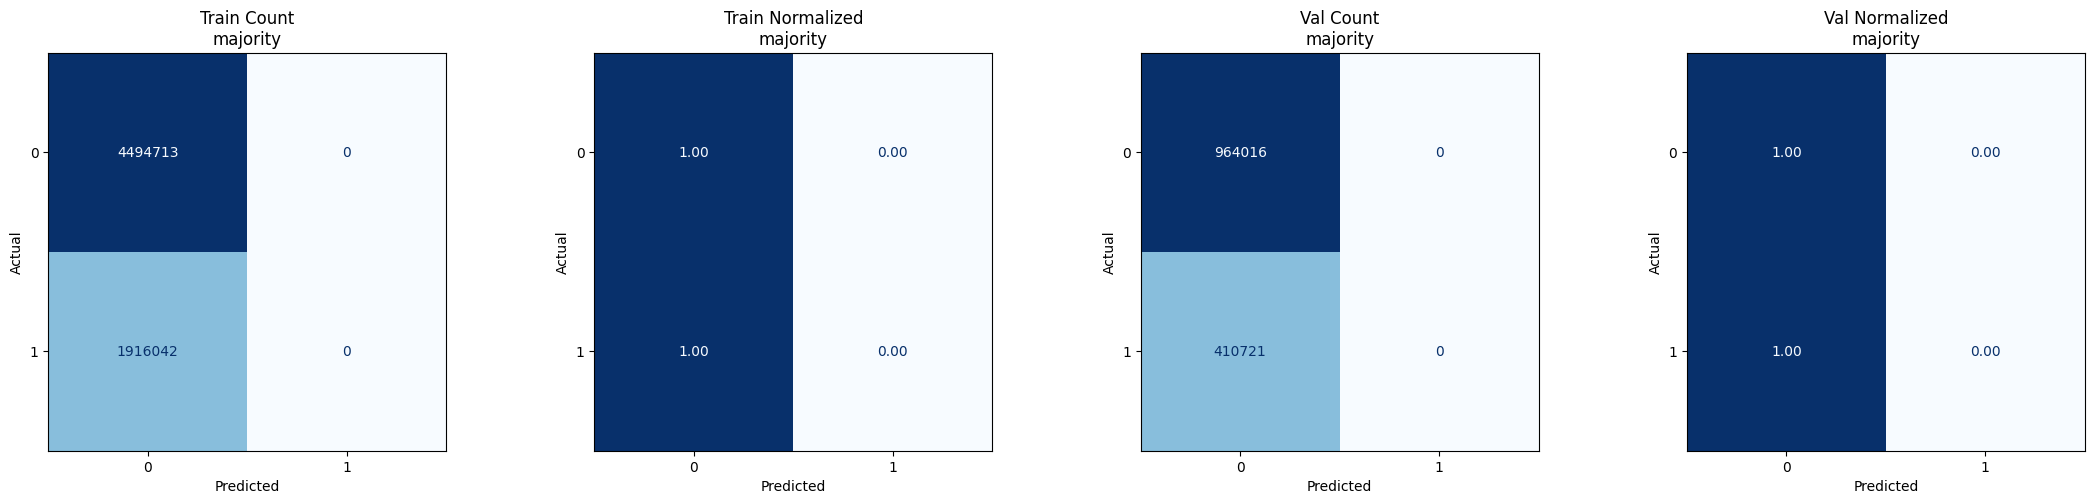

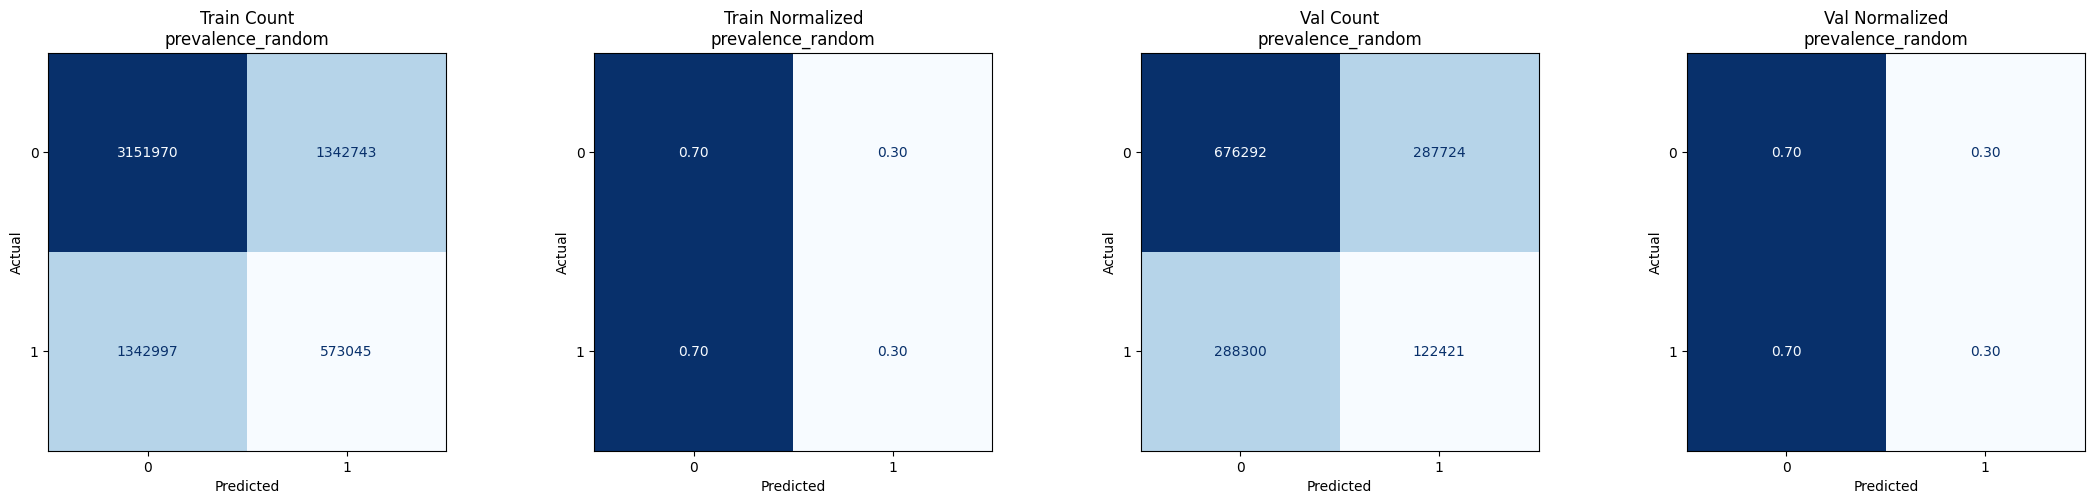

In [15]:
# Example usage (is_helpful baselines):
plot_confusion_matrices(
    train_df,
    val_df,
    y_col="is_helpful",
    pred_col_map={
        "majority": "is_helpful_pred_majority",
        "prevalence_random": "is_helpful_pred_prev_rand",
    },
)

In [16]:
# With hard labels, use pred_col as score proxy for AUPRC
helpful_by_game = by_game_classification_metrics(
    val_df.copy(),
    y_col="is_helpful",
    pred_col="is_helpful_pred_prev_rand",
    score_col=None,
    min_rows=500,
)

print("Top 50 games by F1 (is_helpful)")
helpful_by_game.head(50)

Top 50 games by F1 (is_helpful)


,app_name,n_rows,accuracy,f1,f2,precision,recall,specificity,mcc,auprc,roc_auc
0,"Warhammer 40,000: Dawn of War III",1446,0.354080,0.446682,0.344733,0.880841,0.299206,0.725806,0.018345,0.874203,0.512506
1,Bless Online,955,0.427225,0.431983,0.349110,0.714777,0.309524,0.706714,0.016109,0.707104,0.508119
2,Artifact,1432,0.453911,0.425000,0.344212,0.698068,0.305497,0.742798,0.050442,0.672056,0.524148
3,NBA 2K19,674,0.559347,0.418787,0.381598,0.500000,0.360269,0.716180,0.081534,0.462034,0.538225
4,DiRT 4,612,0.557190,0.417204,0.365762,0.544944,0.337979,0.750769,0.097519,0.494637,0.544374
5,X Rebirth,618,0.341424,0.414388,0.321429,0.800000,0.279612,0.650485,-0.057338,0.824013,0.465049
6,Total War: WARHAMMER,3760,0.447872,0.409220,0.335919,0.643113,0.300083,0.707478,0.007954,0.638998,0.503781
7,Cube World,1560,0.421795,0.403439,0.330946,0.635417,0.295543,0.668561,-0.036803,0.653818,0.482052
8,Freeman: Guerrilla Warfare,712,0.414326,0.394775,0.313220,0.697436,0.275304,0.729358,0.004818,0.694816,0.502331
9,BATTALION 1944,1580,0.477215,0.391753,0.330681,0.565957,0.299550,0.705202,0.005157,0.563203,0.502376


In [17]:
# 1) Review length bins
review_len_bins = by_binned_classification_metrics(
    val_df,
    y_col="is_helpful",
    pred_col="is_helpful_pred_prev_rand",
    bin_field="review_length_chars",
    n_bins=10,
    min_rows=500,
    strategy="quantile",
)

# 2) Playtime bins
playtime_bins = by_binned_classification_metrics(
    val_df,
    y_col="is_helpful",
    pred_col="is_helpful_pred_prev_rand",
    bin_field="author.playtime_at_review",
    n_bins=10,
    min_rows=500,
    strategy="quantile",
)

# 3) Author.num_reviews bins
num_reviews_bins = by_binned_classification_metrics(
    val_df,
    y_col="is_helpful",
    pred_col="is_helpful_pred_prev_rand",
    bin_field="author.num_reviews",
)


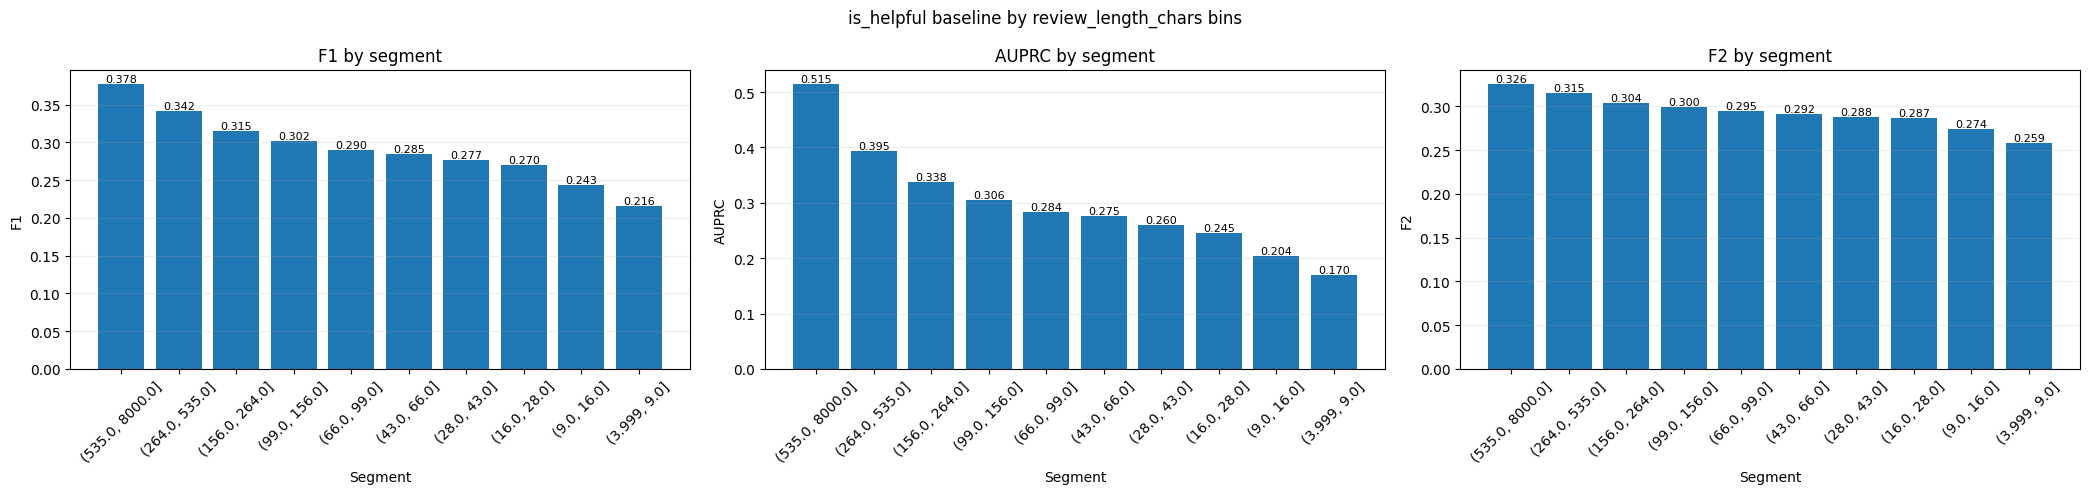

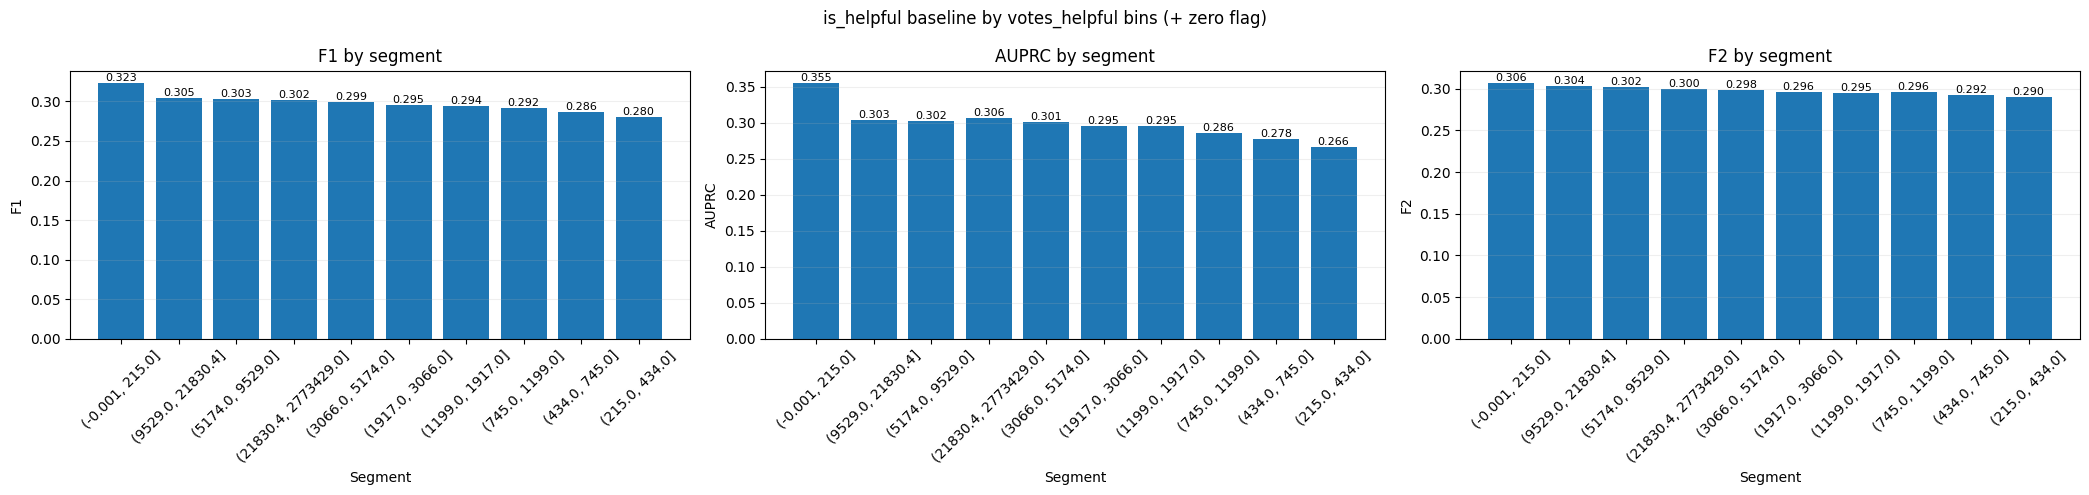

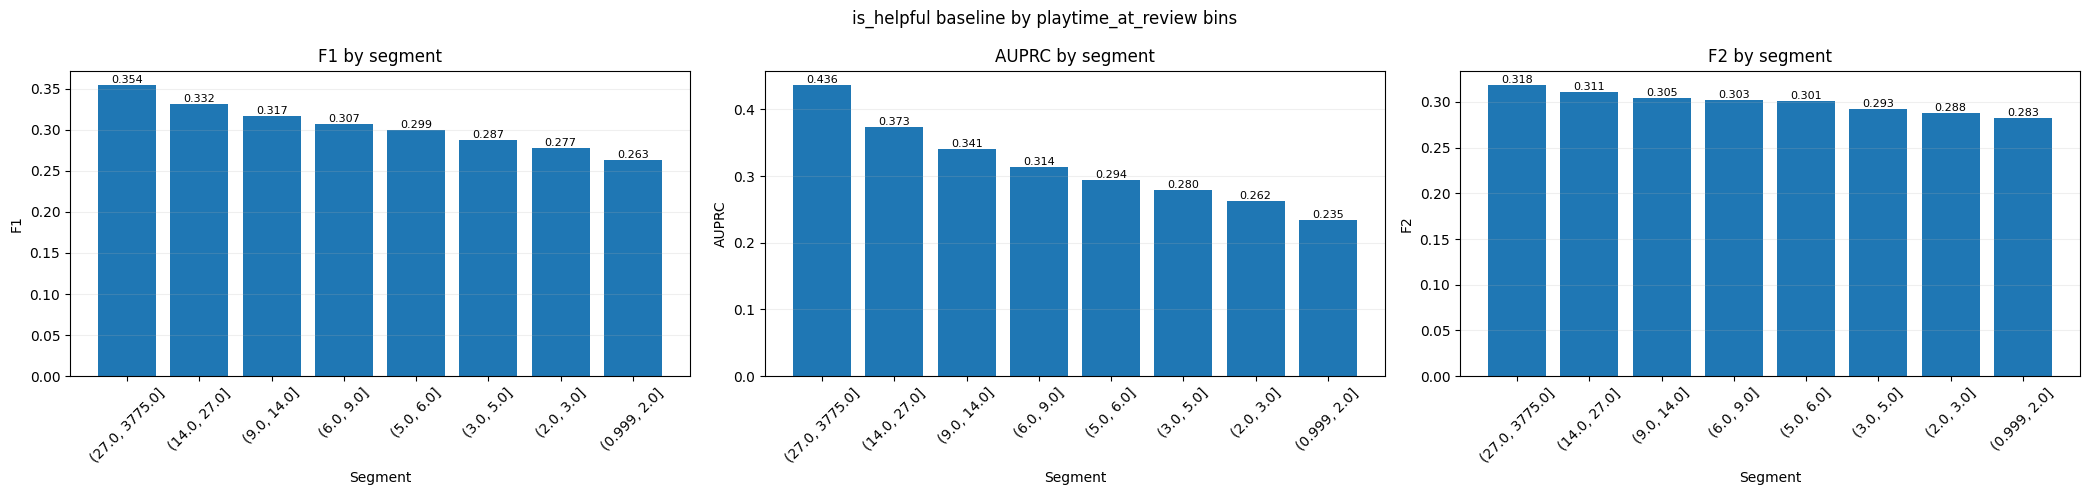

In [18]:
plot_binned_metrics(
    review_len_bins,
    metrics=("f1", "auprc", "f2"),
    title="is_helpful baseline by review_length_chars bins",
)

plot_binned_metrics(
    playtime_bins,
    metrics=("f1", "auprc", "f2"),
    title="is_helpful baseline by votes_helpful bins (+ zero flag)",
)

plot_binned_metrics(
    num_reviews_bins,
    metrics=("f1", "auprc", "f2"),
    title="is_helpful baseline by playtime_at_review bins",
)

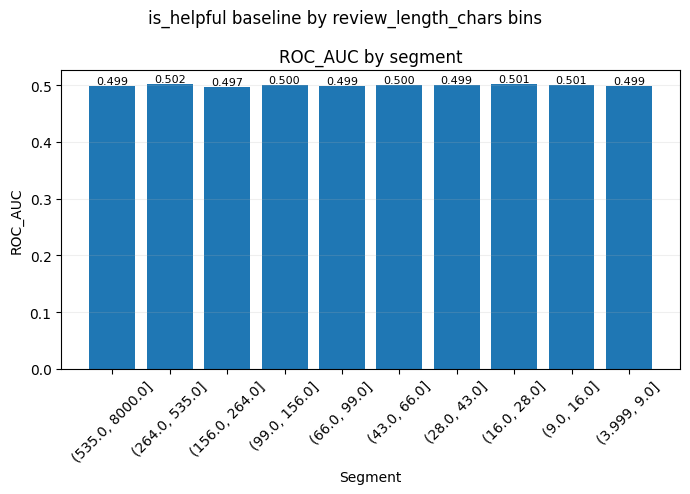

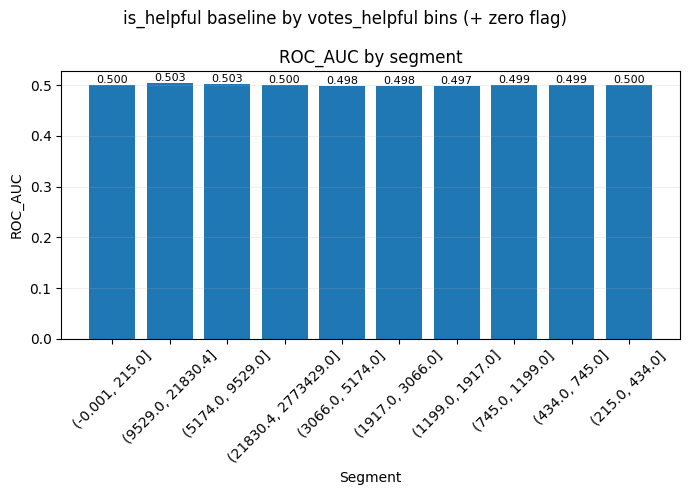

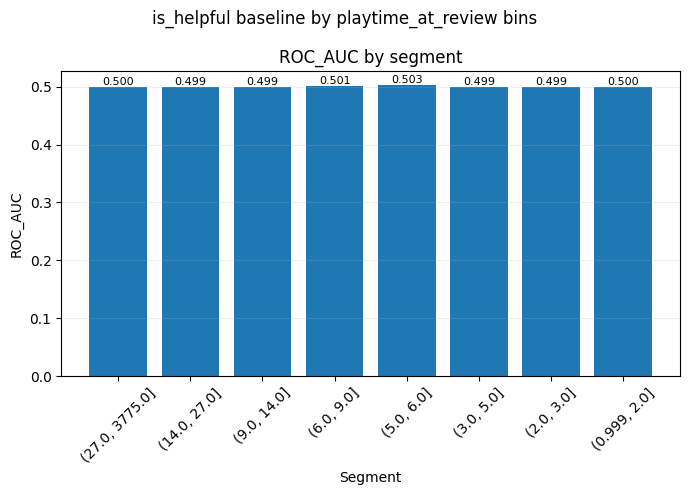

In [19]:
plot_binned_metrics(
    review_len_bins,
    metrics=("roc_auc",),
    title="is_helpful baseline by review_length_chars bins",
)

plot_binned_metrics(
    playtime_bins,
    metrics=("roc_auc",),
    title="is_helpful baseline by votes_helpful bins (+ zero flag)",
)

plot_binned_metrics(
    num_reviews_bins,
    metrics=("roc_auc",),
    title="is_helpful baseline by playtime_at_review bins",
)

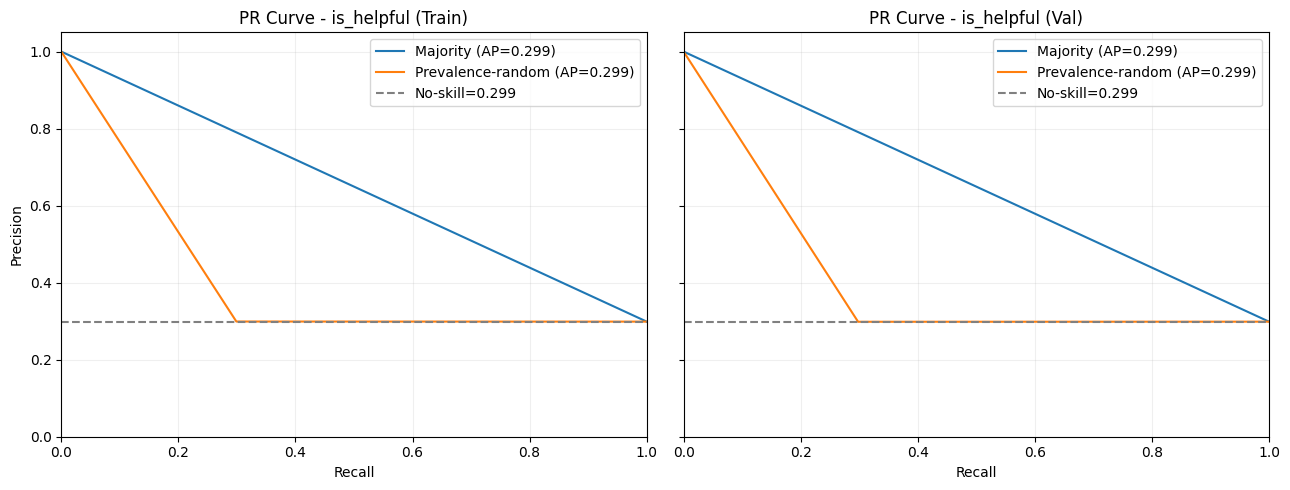

In [20]:
# Example usage (is_helpful):
plot_binary_pr_curves(
    train_df,
    val_df,
    target_col="is_helpful",
    pred_majority_col="is_helpful_pred_majority",
    pred_random_col="is_helpful_pred_prev_rand",
    target_name="is_helpful",
)

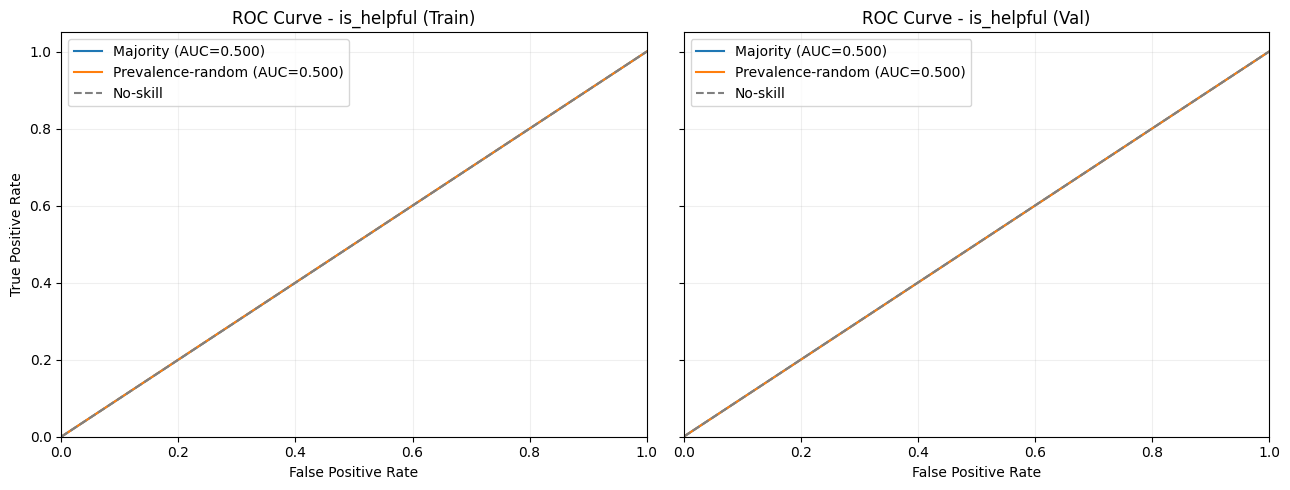

In [21]:
plot_binary_roc_curves(
    train_df,
    val_df,
    target_col="is_helpful",
    pred_majority_col="is_helpful_pred_majority",
    pred_random_col="is_helpful_pred_prev_rand",
    target_name="is_helpful",
)

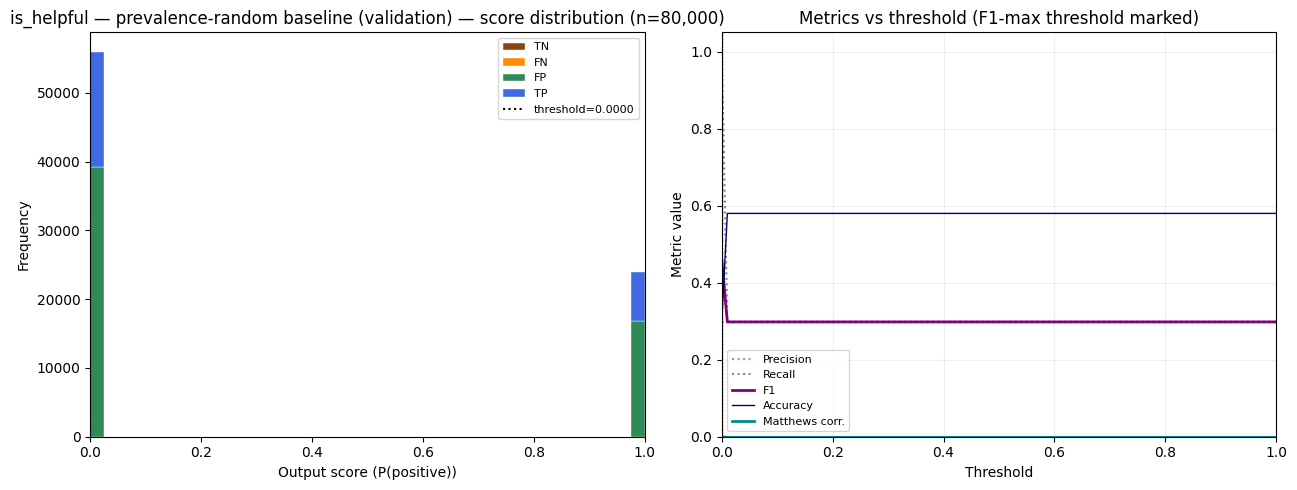

{'threshold_f1_max': 0.0}

In [22]:
# Threshold analysis (validation): score = prevalence-random baseline column (0/1).
# For trained classifiers, pass predicted probability of the positive class instead.
plot_binary_threshold_analysis(
    val_df["is_helpful"].to_numpy(),
    val_df["is_helpful_pred_prev_rand"].astype(float).to_numpy(),
    title="is_helpful — prevalence-random baseline (validation)",
    max_samples=80_000,
    random_state=SEED,
)

# `recommended` Evaluation

`Decision Notes`
- Primary metric - `F1 score`
    - positive class = `recommended == 1`
- Secondary metric - `AUPRC`
    - Metric for probabilistic quality.
- `Specificity` makes negative class explicit, so we're not telling positive class-only details in the F1.
    - Low specificity means many true “not recommended” reviews are labeled recommended (false positives).
- `Recall` (positive class): how well we catch true recommendeds; misses are **false negatives**.
- **Majority baseline** beats prevalence-random on some metrics, but **specificity is 0** (never predicts the negative class), which is untrustworthy if users expect the model to ever say “not recommended.”

We treat **false negatives** (miss a real recommended) and **false positives** (call recommended when they weren’t) as **similarly costly**, so we use **F1** rather than F2.

In [23]:
# ---- Baselines for recommended (binary) ----
recommended_rows = []
for split_name, split_df in [("train", train_df), ("val", val_df)]:
    y_true = split_df["recommended"].to_numpy()

    y_pred_majority = split_df["recommended_pred_majority"].astype(int).to_numpy()
    m = classification_metrics(y_true, y_pred_majority)
    recommended_rows.append({"target": "recommended", "split": split_name, "baseline": "majority", **m})

    y_pred_rand = split_df["recommended_pred_prev_rand"].astype(int).to_numpy()
    m = classification_metrics(y_true, y_pred_rand)
    recommended_rows.append({"target": "recommended", "split": split_name, "baseline": "prevalence_random", **m})

recommended_results = pd.DataFrame(recommended_rows).sort_values(["target", "baseline"]).reset_index(drop=True)
recommended_results

,target,split,baseline,accuracy,f1,f2,precision,recall,specificity,mcc,auprc,roc_auc
0,recommended,train,majority,0.887713,0.940517,0.975326,0.887713,1.000000,0.000000,0.000000,0.887713,0.500000
1,recommended,val,majority,0.887523,0.940410,0.975280,0.887523,1.000000,0.000000,0.000000,0.887523,0.500000
2,recommended,train,prevalence_random,0.800514,0.887635,0.887607,0.887680,0.887589,0.112116,-0.000295,0.887684,0.499853
3,recommended,val,prevalence_random,0.800606,0.887706,0.887881,0.887412,0.887999,0.111016,-0.000987,0.887425,0.499507


In [24]:
# Example usage:
plot_baseline_metrics_grouped_bar(recommended_results, "recommended")

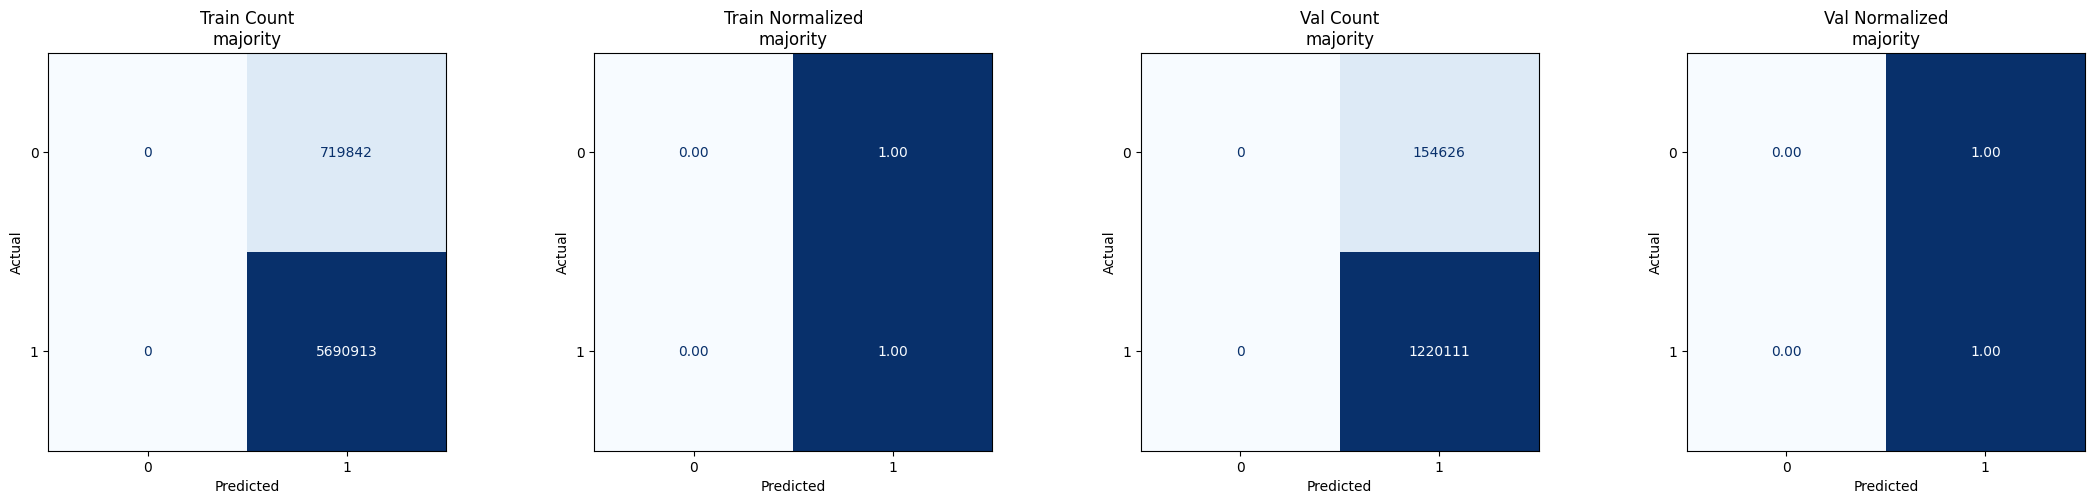

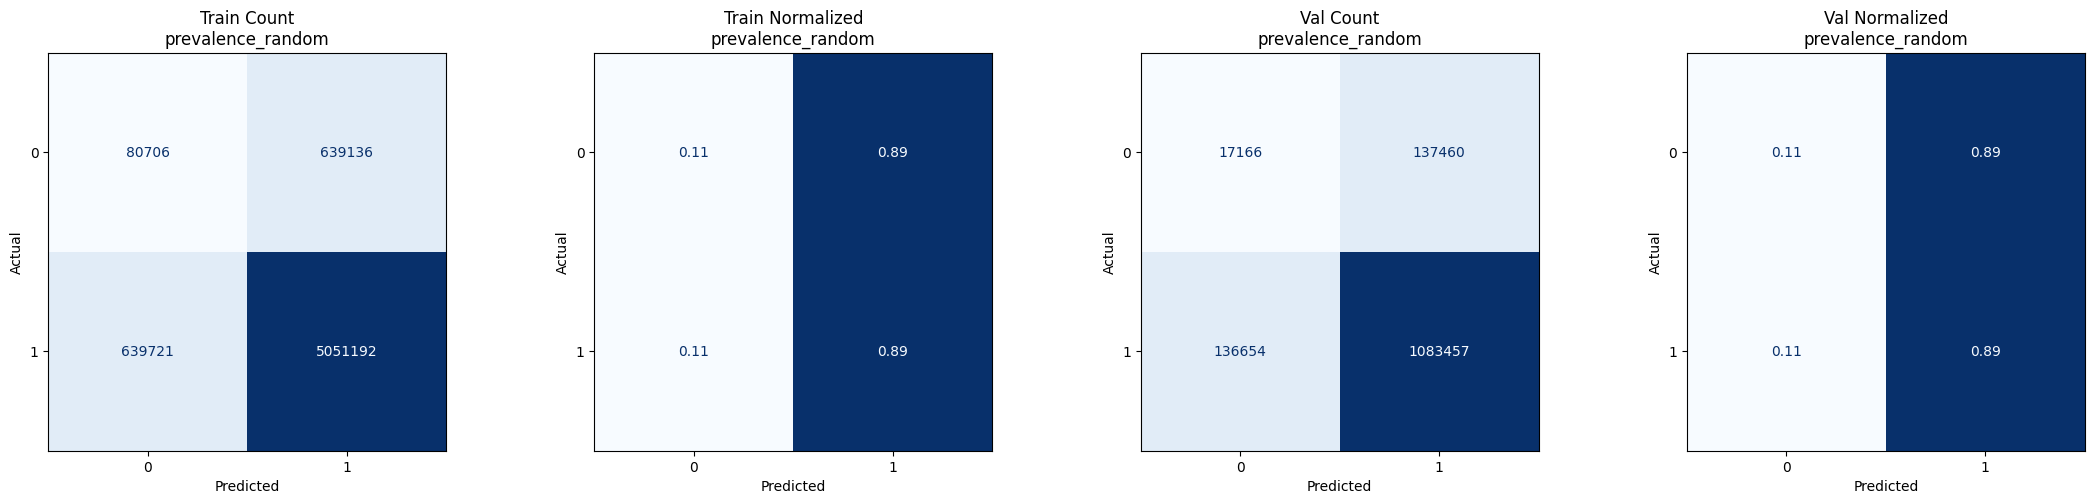

In [25]:
# Confusion matrices for recommended (count + normalized)
plot_confusion_matrices(
    train_df,
    val_df,
    y_col="recommended",
    pred_col_map={
        "majority": "recommended_pred_majority",
        "prevalence_random": "recommended_pred_prev_rand",
    },
)

In [26]:
# By-game metrics for recommended prevalence-random baseline on validation set
recommended_by_game = by_game_classification_metrics(
    val_df.copy(),
    y_col="recommended",
    pred_col="recommended_pred_prev_rand",
    score_col=None,
    min_rows=500,
)

print("Top 15 games by F1 (recommended)")
recommended_by_game.head(50)

Top 15 games by F1 (recommended)


,app_name,n_rows,accuracy,f1,f2,precision,recall,specificity,mcc,auprc,roc_auc
0,Townscaper,650,0.895385,0.944715,0.916982,0.994863,0.899381,0.250000,0.038678,0.994761,0.574690
1,ULTRAKILL,699,0.888412,0.940819,0.910961,0.995185,0.892086,0.250000,0.034429,0.995087,0.571043
2,Keep Talking and Nobody Explodes,857,0.884481,0.938700,0.909964,0.990850,0.891765,0.000000,-0.031470,0.990956,0.445882
3,Hades,9423,0.884219,0.938511,0.909389,0.991427,0.890958,0.076923,-0.009347,0.991459,0.483940
4,A Short Hike,626,0.883387,0.937872,0.907743,0.992793,0.888710,0.333333,0.068223,0.992528,0.611022
5,Stardew Valley,25050,0.882595,0.937541,0.909574,0.988181,0.891838,0.120000,0.004144,0.988164,0.505919
6,Factorio,10022,0.879864,0.936019,0.906480,0.989773,0.887802,0.107843,-0.001385,0.989779,0.497823
7,A Hat in Time,3627,0.879790,0.935977,0.910155,0.982429,0.893718,0.065574,-0.017033,0.982509,0.479646
8,The Henry Stickmin Collection,2148,0.879423,0.935843,0.905040,0.992122,0.885607,0.000000,-0.030020,0.992224,0.442804
9,Portal 2,15591,0.878712,0.935348,0.906038,0.988653,0.887498,0.117978,0.001840,0.988645,0.502738


In [27]:
# Binned metrics for recommended prevalence-random baseline
recommended_review_len_bins = by_binned_classification_metrics(
    val_df,
    y_col="recommended",
    pred_col="recommended_pred_prev_rand",
    bin_field="review_length_chars",
    n_bins=10,
    min_rows=500,
    strategy="quantile",
)

recommended_playtime_bins = by_binned_classification_metrics(
    val_df,
    y_col="recommended",
    pred_col="recommended_pred_prev_rand",
    bin_field="author.playtime_at_review",
    n_bins=10,
    min_rows=500,
    strategy="quantile",
)

recommended_num_reviews_bins = by_binned_classification_metrics(
    val_df,
    y_col="recommended",
    pred_col="recommended_pred_prev_rand",
    bin_field="author.num_reviews",
)

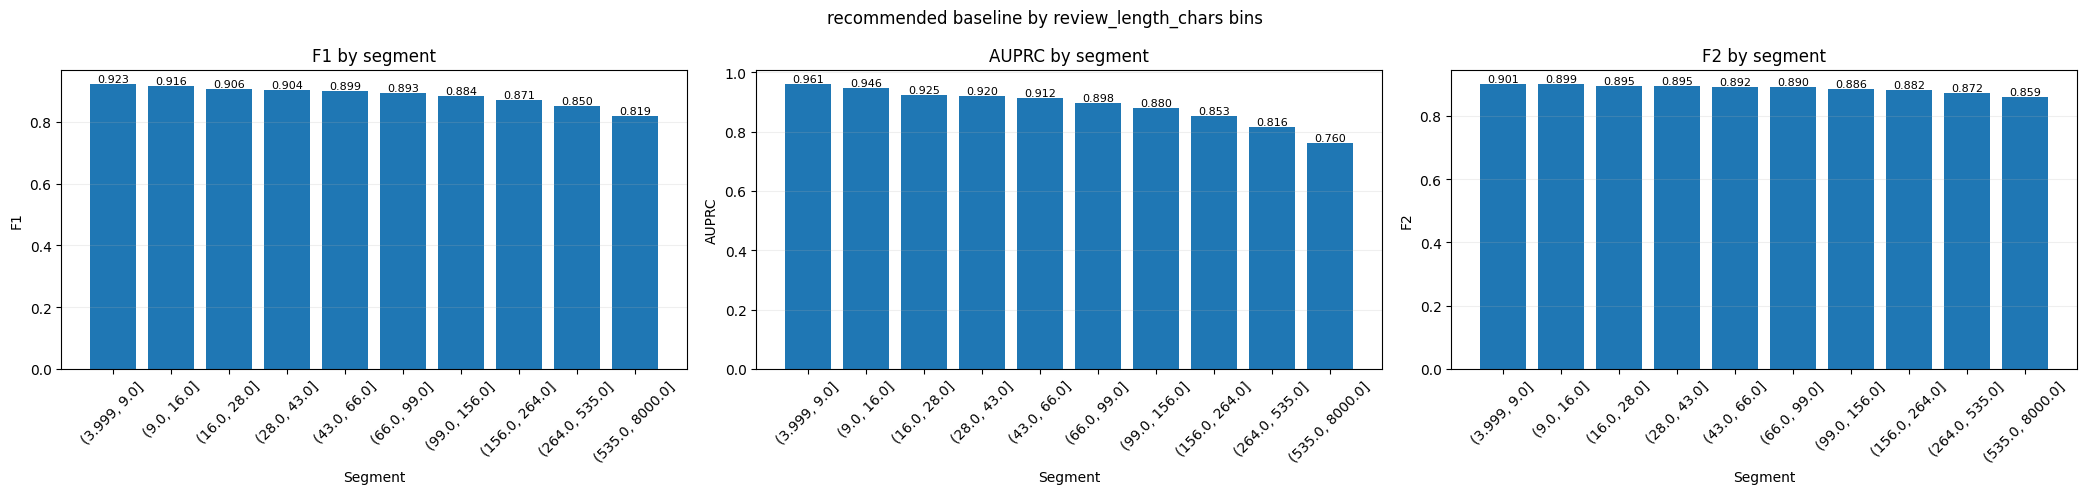

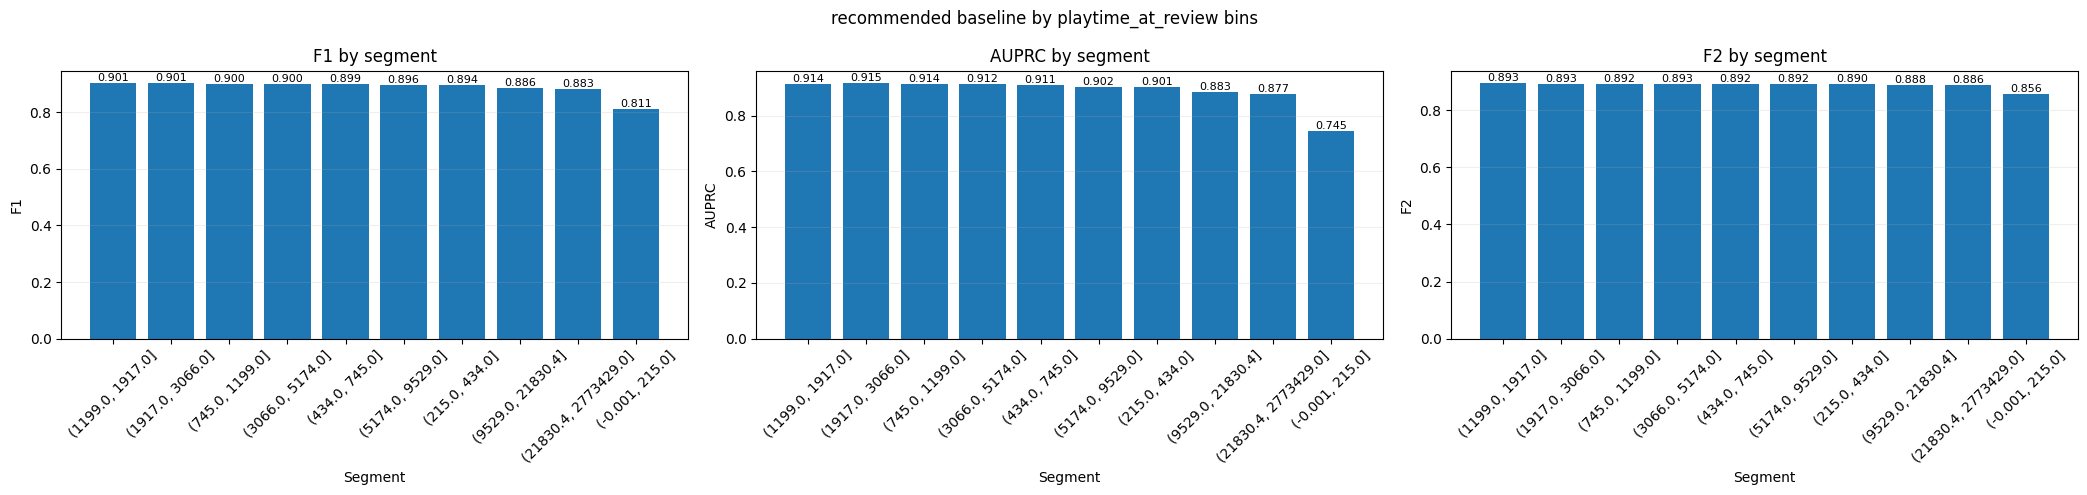

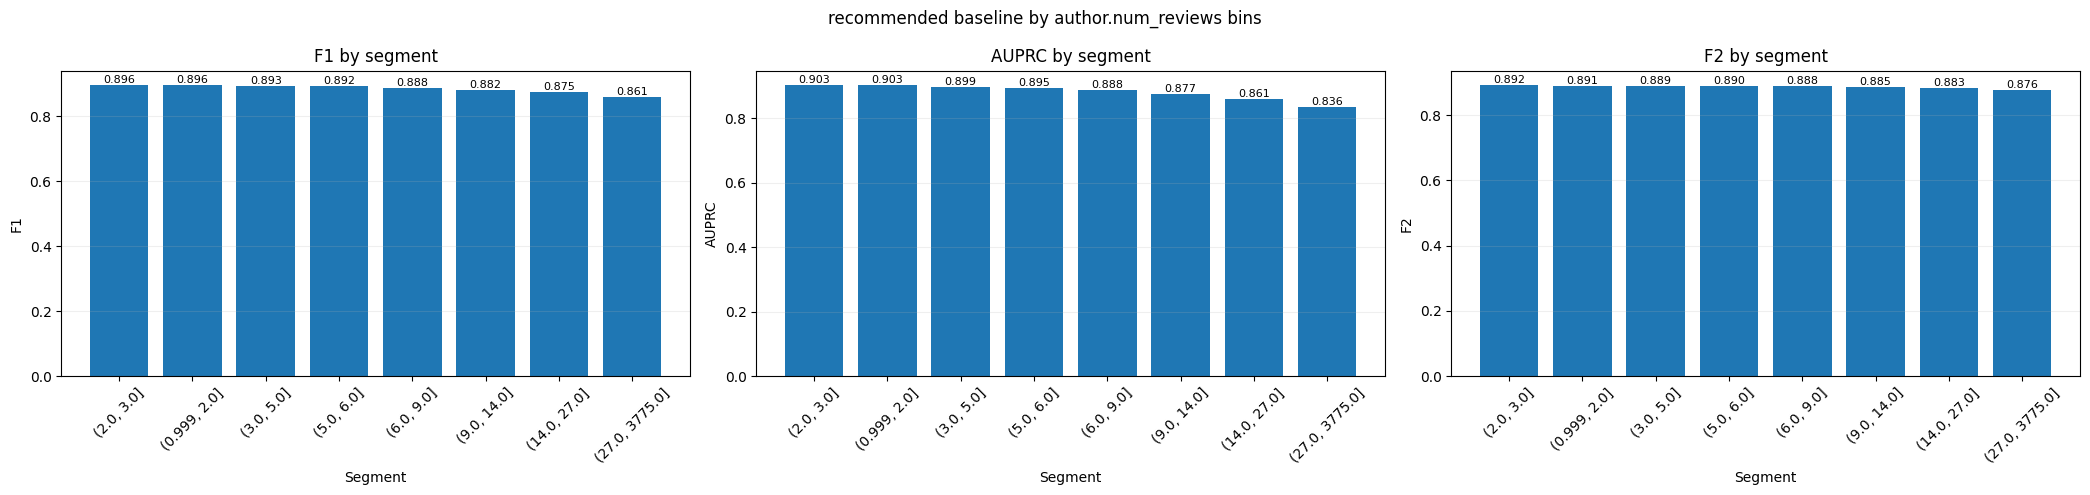

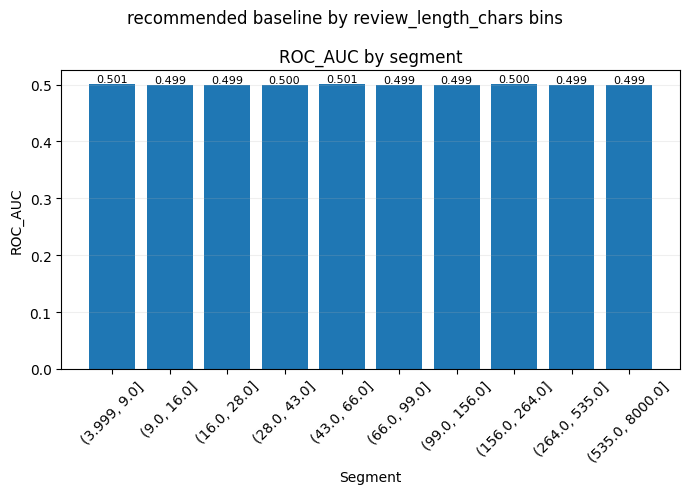

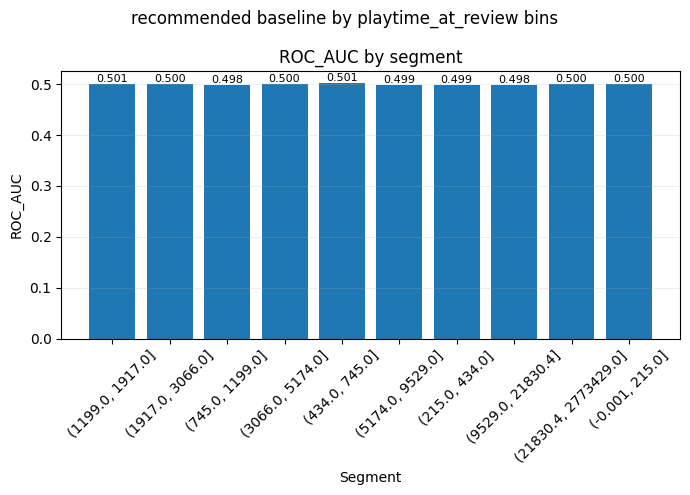

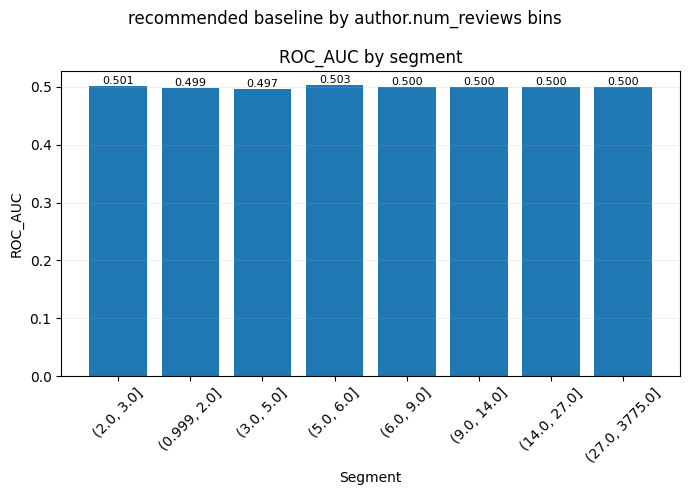

In [28]:
plot_binned_metrics(
    recommended_review_len_bins,
    metrics=("f1", "auprc", "f2"),
    title="recommended baseline by review_length_chars bins",
)

plot_binned_metrics(
    recommended_playtime_bins,
    metrics=("f1", "auprc", "f2"),
    title="recommended baseline by playtime_at_review bins",
)

plot_binned_metrics(
    recommended_num_reviews_bins,
    metrics=("f1", "auprc", "f2"),
    title="recommended baseline by author.num_reviews bins",
)

plot_binned_metrics(
    recommended_review_len_bins,
    metrics=("roc_auc",),
    title="recommended baseline by review_length_chars bins",
)

plot_binned_metrics(
    recommended_playtime_bins,
    metrics=("roc_auc",),
    title="recommended baseline by playtime_at_review bins",
)

plot_binned_metrics(
    recommended_num_reviews_bins,
    metrics=("roc_auc",),
    title="recommended baseline by author.num_reviews bins",
)

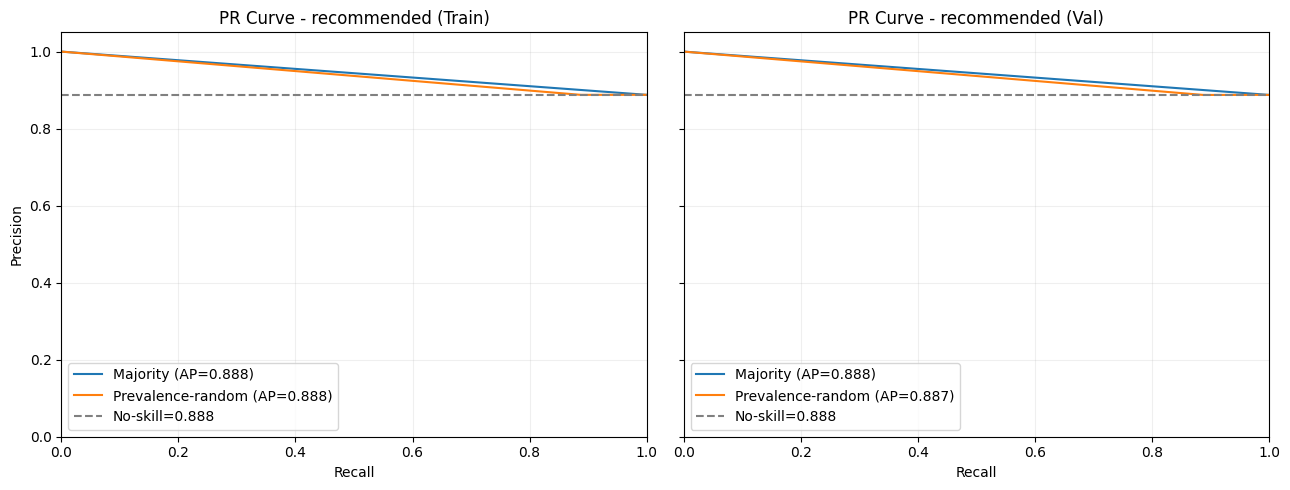

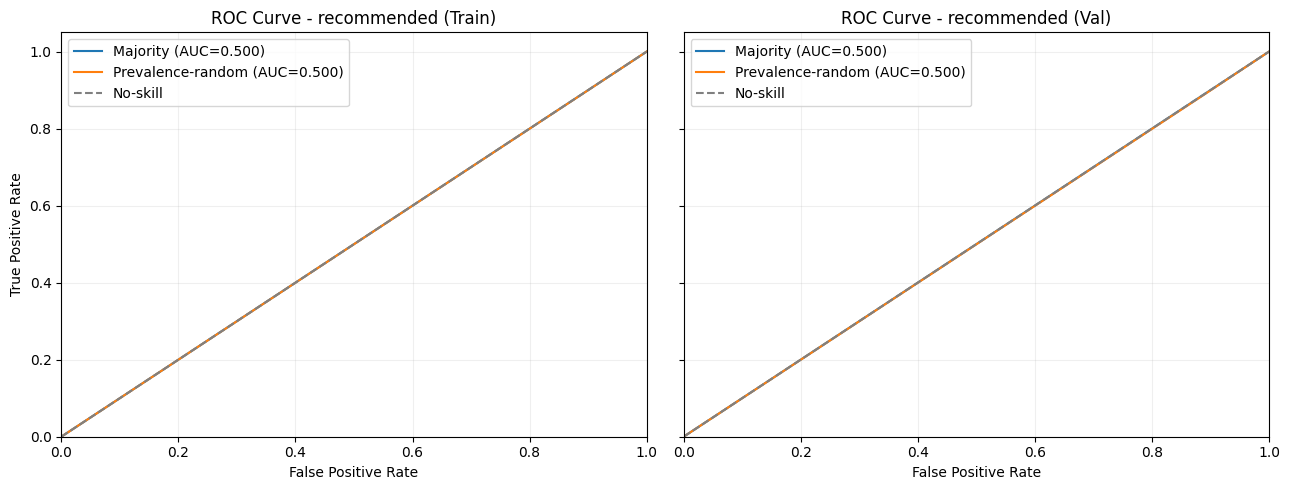

In [29]:
# PR/ROC for recommended baselines (train + val)
plot_binary_pr_curves(
    train_df,
    val_df,
    target_col="recommended",
    pred_majority_col="recommended_pred_majority",
    pred_random_col="recommended_pred_prev_rand",
    target_name="recommended",
)

plot_binary_roc_curves(
    train_df,
    val_df,
    target_col="recommended",
    pred_majority_col="recommended_pred_majority",
    pred_random_col="recommended_pred_prev_rand",
    target_name="recommended",
)

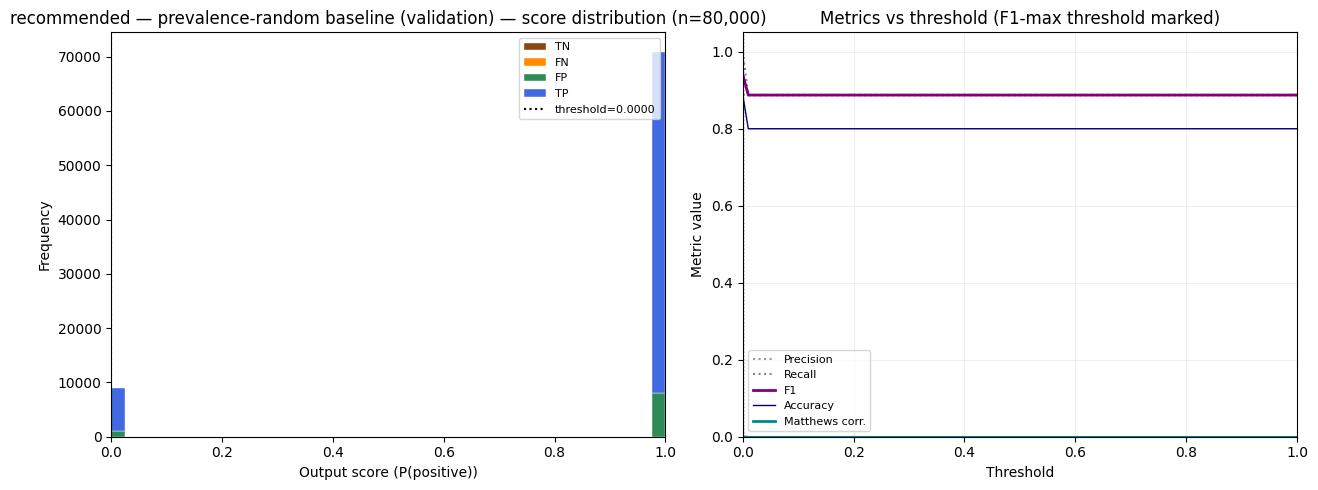

{'threshold_f1_max': 0.0}

In [30]:
# Threshold analysis (validation): score = prevalence-random baseline column (0/1).
# For trained classifiers, pass predicted probability of the positive class instead.
plot_binary_threshold_analysis(
    val_df["recommended"].to_numpy(),
    val_df["recommended_pred_prev_rand"].astype(float).to_numpy(),
    title="recommended — prevalence-random baseline (validation)",
    max_samples=80_000,
    random_state=SEED,
)

# `votes_helpful` Evaluation

**Decisions**

- Easy failure mode: the model **mostly predicts 0** (or hugs the mean) because votes are **skewed** and a lot of rows are **0**. Plain accuracy-style thinking doesn’t apply; use metrics and baselines that **punish** that lazy behavior.

- **Primary: weighted MAE** — *say in the notebook what the weights are* (equal weights = plain MAE; or e.g. upweight rows you care about more). That’s the main number for comparing models.

- **Secondary: Spearman** — “do we get **ranking / strength** roughly right?” Catches models that look okay on average error but **don’t** separate high-vote from low-vote reviews.

- **R²** — **sanity / diagnostic** (did we beat predicting the mean?). Not what I’m optimizing.

- Compare against the **dumb baselines** in this notebook (zeros, mean, etc.). A real model should **beat** those on the primary metric **and** not tank Spearman.


In [31]:
# Value counts of votes_helpful binned into 50 bins
# Show as a table instead of a graph.
print(train_df["is_helpful"].value_counts())
# Bin the votes_helpful values (across all splits) into 50 bins, show as a DataFrame
all_votes_helpful = pd.concat([train_df["votes_helpful"], val_df["votes_helpful"]])
counts, bin_edges = np.histogram(all_votes_helpful, bins=50)

# Create a DataFrame with bin ranges and counts
bin_ranges = [f"[{bin_edges[i]:.1f}, {bin_edges[i+1]:.1f})" for i in range(len(bin_edges)-1)]
votes_binned_df = pd.DataFrame({
    "bin_range": bin_ranges,
    "count": counts
})

votes_binned_df.head(20)

is_helpful
0    4494713
1    1916042
Name: count, dtype: int64


,bin_range,count
0,"[0.0, 592.2)",7782566
1,"[592.2, 1184.3)",1792
2,"[1184.3, 1776.5)",546
3,"[1776.5, 2368.6)",220
4,"[2368.6, 2960.8)",98
5,"[2960.8, 3553.0)",66
6,"[3553.0, 4145.1)",47
7,"[4145.1, 4737.3)",39
8,"[4737.3, 5329.4)",26
9,"[5329.4, 5921.6)",16


In [32]:
# ---- Baselines for votes_helpful (count / regression-style) ----
votes_rows = []
for split_name, split_df in [("train", train_df), ("val", val_df)]:
    y_true = split_df["votes_helpful"].astype(float).to_numpy()

    y_pred_zero = split_df["votes_helpful_pred_all_zero"].astype(float).to_numpy()
    m = regression_metrics(y_true, y_pred_zero)
    votes_rows.append({"target": "votes_helpful", "split": split_name, "baseline": "all_zero", **m})

    y_pred_mean = split_df["votes_helpful_pred_train_mean"].astype(float).to_numpy()
    m = regression_metrics(y_true, y_pred_mean)
    votes_rows.append({"target": "votes_helpful", "split": split_name, "baseline": "train_mean", **m})

    y_pred_emp = split_df["votes_helpful_pred_empirical_random"].astype(float).to_numpy()
    m = regression_metrics(y_true, y_pred_emp)
    votes_rows.append({"target": "votes_helpful", "split": split_name, "baseline": "empirical_random", **m})

pd.DataFrame(votes_rows)

,target,split,baseline,mae,mse,rmse,r2,mape_pct
0,votes_helpful,train,all_zero,2.011896,2161.199622,46.488704,-1.876422e-03,2.988793e+01
1,votes_helpful,train,train_mean,3.173952,2157.151895,46.445149,0.000000e+00,1.410582e+10
2,votes_helpful,train,empirical_random,3.784184,4326.412044,65.775467,-1.005613e+00,1.420201e+10
3,votes_helpful,val,all_zero,2.025414,2528.213436,50.281343,-1.625247e-03,2.987633e+01
4,votes_helpful,val,train_mean,3.187729,2524.111315,50.240535,-7.239525e-08,1.410816e+10
5,votes_helpful,val,empirical_random,3.808185,5005.919294,70.752521,-9.832404e-01,1.427697e+10


# Side-by-side Evaluation of all three metrics

In [33]:
# Combined quick summary (train + validation) only
summary = pd.concat(
    [
        pd.DataFrame(recommended_rows),
        pd.DataFrame(votes_rows),
        pd.DataFrame(is_helpful_rows),
    ],
    ignore_index=True,
).sort_values(["target", "baseline", "split"])
summary

,target,split,baseline,accuracy,f1,f2,precision,recall,specificity,mcc,auprc,roc_auc,mae,mse,rmse,r2,mape_pct
10,is_helpful,train,majority,0.701121,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.298879,0.500000,NaN,NaN,NaN,NaN,NaN
12,is_helpful,val,majority,0.701237,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.298763,0.500000,NaN,NaN,NaN,NaN,NaN
11,is_helpful,train,prevalence_random,0.581057,0.299097,0.299085,0.299117,0.299077,0.701262,0.000339,0.298950,0.500170,NaN,NaN,NaN,NaN,NaN
13,is_helpful,val,prevalence_random,0.580993,0.298273,0.298147,0.298482,0.298064,0.701536,-0.000400,0.298680,0.499800,NaN,NaN,NaN,NaN,NaN
0,recommended,train,majority,0.887713,0.940517,0.975326,0.887713,1.000000,0.000000,0.000000,0.887713,0.500000,NaN,NaN,NaN,NaN,NaN
2,recommended,val,majority,0.887523,0.940410,0.975280,0.887523,1.000000,0.000000,0.000000,0.887523,0.500000,NaN,NaN,NaN,NaN,NaN
1,recommended,train,prevalence_random,0.800514,0.887635,0.887607,0.887680,0.887589,0.112116,-0.000295,0.887684,0.499853,NaN,NaN,NaN,NaN,NaN
3,recommended,val,prevalence_random,0.800606,0.887706,0.887881,0.887412,0.887999,0.111016,-0.000987,0.887425,0.499507,NaN,NaN,NaN,NaN,NaN
4,votes_helpful,train,all_zero,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.011896,2161.199622,46.488704,-1.876422e-03,2.988793e+01
7,votes_helpful,val,all_zero,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.025414,2528.213436,50.281343,-1.625247e-03,2.987633e+01


In [34]:
# Plot metrics for a single target as grouped bars (train/val); store target in a variable.
# This version omits subplot grid and background coloring for clarity.

# Visualize baseline results for a single target (`is_helpful`) as grouped bar charts.
target_to_plot = "recommended"

metrics = [
    ("accuracy", "Accuracy"),
    ("f1", "F1 Score"),
    ("precision", "Precision"),
    ("recall", "Recall"),
]
splits = ['train', 'val']
split_colors = {'train': 'dodgerblue', 'val': 'firebrick'}

# Filter DataFrame to the selected target
target_df = summary[summary['target'] == target_to_plot].copy()
baselines = target_df['baseline'].unique()

# Only plot metrics that are present and not all NaN for this target
visible_metrics = [(metric, label) for metric, label in metrics
                   if metric in target_df.columns and target_df[metric].notnull().any()]

for baseline in baselines:
    fig = go.Figure()
    baseline_df = target_df[target_df['baseline'] == baseline]

    for split in splits:
        split_df = baseline_df[baseline_df['split'] == split]
        y_values = []
        for metric, _ in visible_metrics:
            val = split_df[metric].values
            if len(val) > 0:
                y_values.append(val[0])
            else:
                y_values.append(None)
        fig.add_bar(
            x=[label for _, label in visible_metrics],
            y=y_values,
            name=split.capitalize(),
            marker_color=split_colors[split],
            text=[f"{v:.4f}" if v is not None and not (isinstance(v, float) and (v != v)) else "" for v in y_values],
            textposition='auto'
        )
    fig.update_layout(
        title=f"Baseline '{baseline}' for target '{target_to_plot}' (train vs. val)",
        barmode='group',
        xaxis_title="Metric",
        yaxis_title="Score",
        legend_title="Split",
        plot_bgcolor='white',
        margin=dict(t=70, l=20, r=20, b=20),
        width=90 + 150 * len(visible_metrics),
        height=400,
    )
    fig.show()


# By-Game Metrics (Validation)

Use this section to inspect where a baseline performs well/poorly by `app_name`.

Tip: set a minimum row threshold so tiny games do not dominate the ranking noise.

In [35]:
def by_game_classification_metrics(df, y_col, pred_col, score_col=None, min_rows=200):
    rows = []
    for game, g in df.groupby("app_name"):
        if len(g) < min_rows:
            continue

        y_true = g[y_col].astype(int).to_numpy()
        y_pred = g[pred_col].astype(int).to_numpy()
        y_score = g[score_col].to_numpy() if score_col is not None else None

        m = classification_metrics(y_true, y_pred, y_score=y_score)
        rows.append({"app_name": game, "n_rows": len(g), **m})

    out = pd.DataFrame(rows)
    if len(out) == 0:
        return out
    return out.sort_values(["f1", "auprc"], ascending=[False, False]).reset_index(drop=True)


# Example: by-game metrics for recommended prevalence-random baseline on validation set
val_game = val_df.copy()
val_game["recommended_true"] = val_game["recommended"].astype(int)
val_game["recommended_pred_prev_rand"] = rng.binomial(1, p_rec, size=len(val_game))

# With hard labels, we use pred_col as score proxy for AUPRC.
rec_by_game = by_game_classification_metrics(
    val_game,
    y_col="recommended_true",
    pred_col="recommended_pred_prev_rand",
    score_col=None,
    min_rows=500,
)

print("Top 15 games by F1")
rec_by_game.head(15)


Top 15 games by F1


,app_name,n_rows,accuracy,f1,f2,precision,recall,specificity,mcc,auprc,roc_auc
0,The Henry Stickmin Collection,2148,0.895717,0.944909,0.917821,0.993792,0.900609,0.200000,0.027915,0.993715,0.550305
1,ULTRAKILL,699,0.892704,0.943311,0.915493,0.993631,0.897842,0.000000,-0.025509,0.993697,0.448921
2,Finding Paradise,576,0.885417,0.939002,0.915645,0.980695,0.900709,0.166667,0.031978,0.980543,0.533688
3,Hades,9423,0.883370,0.938004,0.908396,0.991887,0.889674,0.128205,0.005167,0.991869,0.508939
4,Factorio,10022,0.882359,0.937397,0.908258,0.990351,0.889819,0.156863,0.014936,0.990293,0.523341
5,Totally Accurate Battle Simulator,4479,0.882117,0.937203,0.911193,0.984016,0.894641,0.146667,0.017214,0.983936,0.520654
6,Portal 2,15591,0.881727,0.937078,0.908796,0.988339,0.890871,0.089888,-0.006562,0.988366,0.490379
7,Danganronpa 2: Goodbye Despair,1028,0.881323,0.936722,0.917310,0.970968,0.904810,0.100000,0.002757,0.970953,0.502405
8,Stardew Valley,25050,0.880599,0.936420,0.907967,0.988023,0.889939,0.110000,-0.000021,0.988023,0.499970
9,RimWorld,8690,0.880437,0.936301,0.909632,0.984401,0.892682,0.110294,0.001193,0.984396,0.501488


In [36]:
print("Bottom 15 games by F1")
rec_by_game.sort_values(["f1", "auprc"], ascending=[True, True]).head(15)

Bottom 15 games by F1


,app_name,n_rows,accuracy,f1,f2,precision,recall,specificity,mcc,auprc,roc_auc
227,NBA 2K18,550,0.361818,0.476900,0.663900,0.324544,0.898876,0.104839,0.005703,0.324452,0.501858
226,Bless Online,955,0.379058,0.489233,0.675226,0.335301,0.904459,0.121685,0.038780,0.334680,0.513072
225,Cube World,1560,0.382692,0.507920,0.681008,0.356784,0.881206,0.100402,-0.028581,0.357349,0.490804
224,X Rebirth,618,0.391586,0.516710,0.701816,0.358929,0.922018,0.102500,0.040174,0.358447,0.512259
223,Nether,1570,0.395541,0.526211,0.701171,0.371650,0.900855,0.095431,-0.006072,0.371746,0.498143
222,NBA 2K21,581,0.452668,0.583770,0.735003,0.434698,0.888446,0.121212,0.014883,0.434398,0.504829
221,Call of Duty: Infinite Warfare,1587,0.466919,0.609779,0.758375,0.459666,0.905479,0.093349,-0.002002,0.459697,0.499414
220,ATLAS,2795,0.476923,0.613636,0.751067,0.470231,0.882890,0.116216,-0.001390,0.470260,0.499553
219,"Warhammer 40,000: Dawn of War III",1446,0.486860,0.623350,0.774275,0.470498,0.923308,0.115237,0.064758,0.469684,0.519273
218,NBA 2K19,674,0.501484,0.647059,0.776210,0.506579,0.895349,0.090909,-0.023113,0.506977,0.493129
